<a href="https://colab.research.google.com/github/iqlore-collab/REGRESSION-BOOSTING---SUPERVISED-ML/blob/main/housing_price_regression_full_project_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Housing Price Prediction — Regression ML Project

I built this notebook as a full end-to-end supervised machine learning project for predicting house prices.

The project focuses only on **regression**.  
No classification. No unsupervised learning. Just a clean, focused housing price prediction workflow.

## What this notebook includes

- Google Colab + Google Drive dataset loading
- Exploratory Data Analysis
- strong visualizations
- feature engineering
- preprocessing pipelines
- Linear Regression baseline
- Random Forest
- XGBoost
- feature importance
- feature selection
- model comparison
- residual analysis
- final business-style conclusions

Dataset path used in this project:

```python
/content/drive/MyDrive/Colab Notebooks/housing_iteration_6_regression.csv
```

## 1. Environment Setup

First, I mount Google Drive and load the libraries needed for the project.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Feature selection
from sklearn.feature_selection import SelectKBest, f_regression, SelectFromModel, RFE
from sklearn.feature_selection import VarianceThreshold

# XGBoost
try:
    from xgboost import XGBRegressor
except ImportError:
    import sys
    !{sys.executable} -m pip install xgboost -q
    from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid")

## 2. Load the Dataset

I load the housing dataset directly from Google Drive.  
This keeps the notebook clean and reproducible in Google Colab.

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/housing_iteration_6_regression.csv"

housing = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Dataset shape: {housing.shape}")

housing.head()

Dataset loaded successfully!
Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Quick Dataset Overview

Before building any model, I want to understand what the dataset looks like.

In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [ ]:
TARGET = "SalePrice"

if TARGET not in housing.columns:
    raise ValueError(f"Target column '{TARGET}' was not found in the dataset.")

print("Target column:", TARGET)
print("Missing values in target:", housing[TARGET].isna().sum())

Target column: SalePrice
Missing values in target: 0


## 4. Missing Values Overview

Missing values are not automatically bad, but I need to know where they are.  
This visualization helps me quickly identify the columns that need attention.

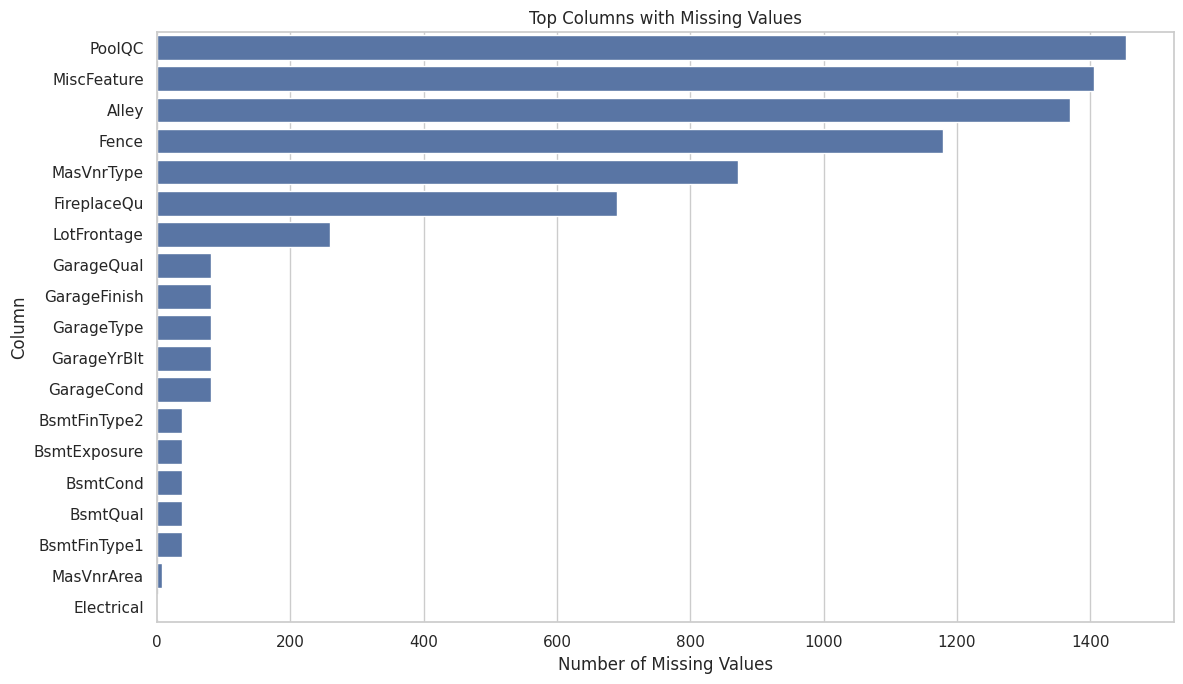

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [ ]:
missing = housing.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(12, 7))
sns.barplot(x=missing.head(25).values, y=missing.head(25).index)
plt.title("Top Columns with Missing Values")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

missing.head(25)

## 5. Feature Types

Here I check how many numeric and categorical variables the dataset contains.

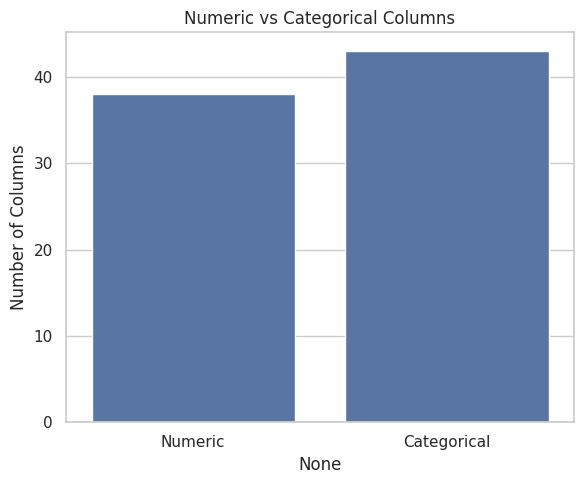

,0
Numeric,38
Categorical,43


In [ ]:
numeric_cols = housing.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = housing.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

feature_type_counts = pd.Series({
    "Numeric": len(numeric_cols),
    "Categorical": len(categorical_cols)
})

plt.figure(figsize=(6, 5))
sns.barplot(x=feature_type_counts.index, y=feature_type_counts.values)
plt.title("Numeric vs Categorical Columns")
plt.ylabel("Number of Columns")
plt.tight_layout()
plt.show()

feature_type_counts

## 6. Target Variable Analysis

`SalePrice` is the variable I want to predict.  
Understanding its distribution is super important before modeling.

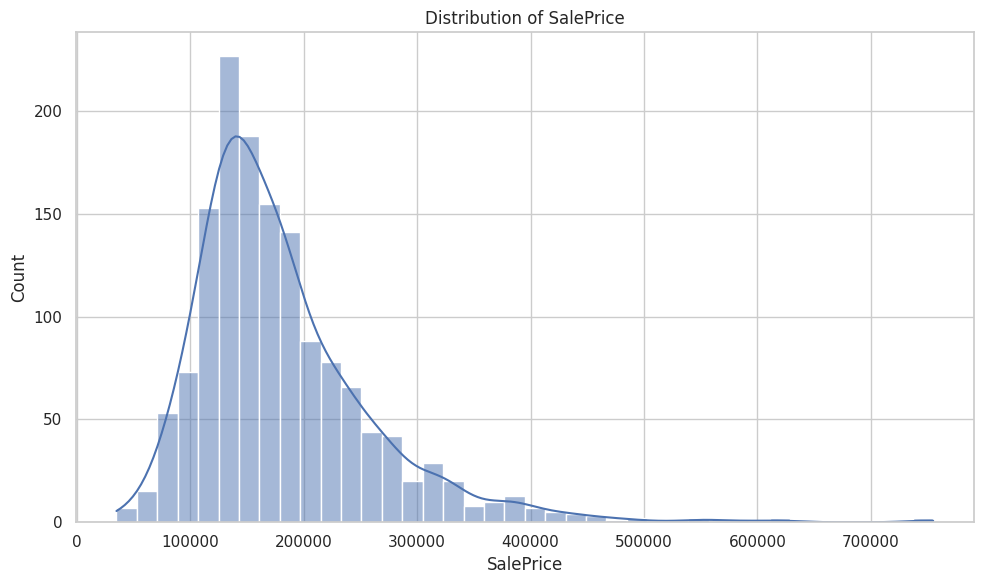

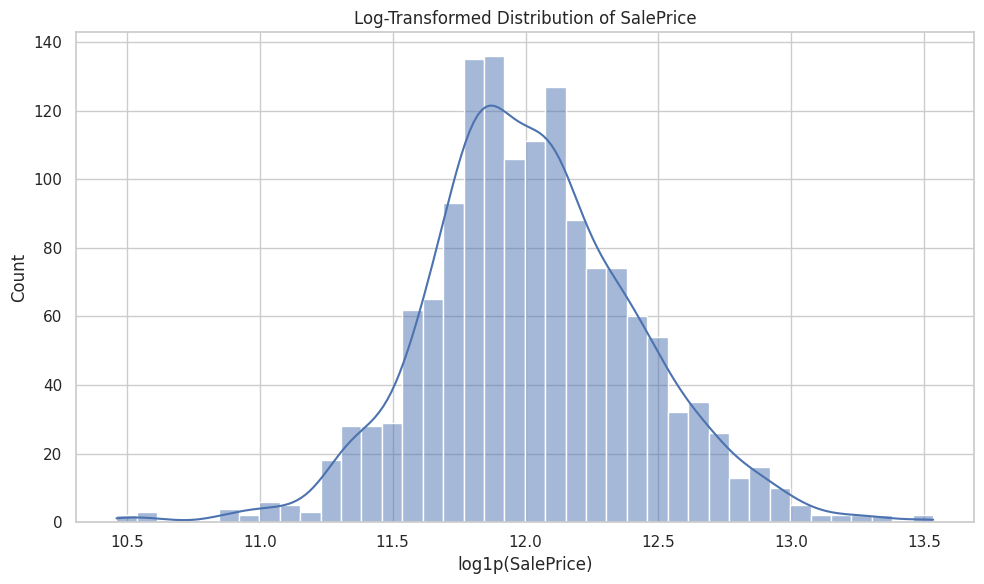

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(housing[TARGET], kde=True, bins=40)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(housing[TARGET]), kde=True, bins=40)
plt.title("Log-Transformed Distribution of SalePrice")
plt.xlabel("log1p(SalePrice)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

This gives me a first look at the strongest numeric relationships with house price.

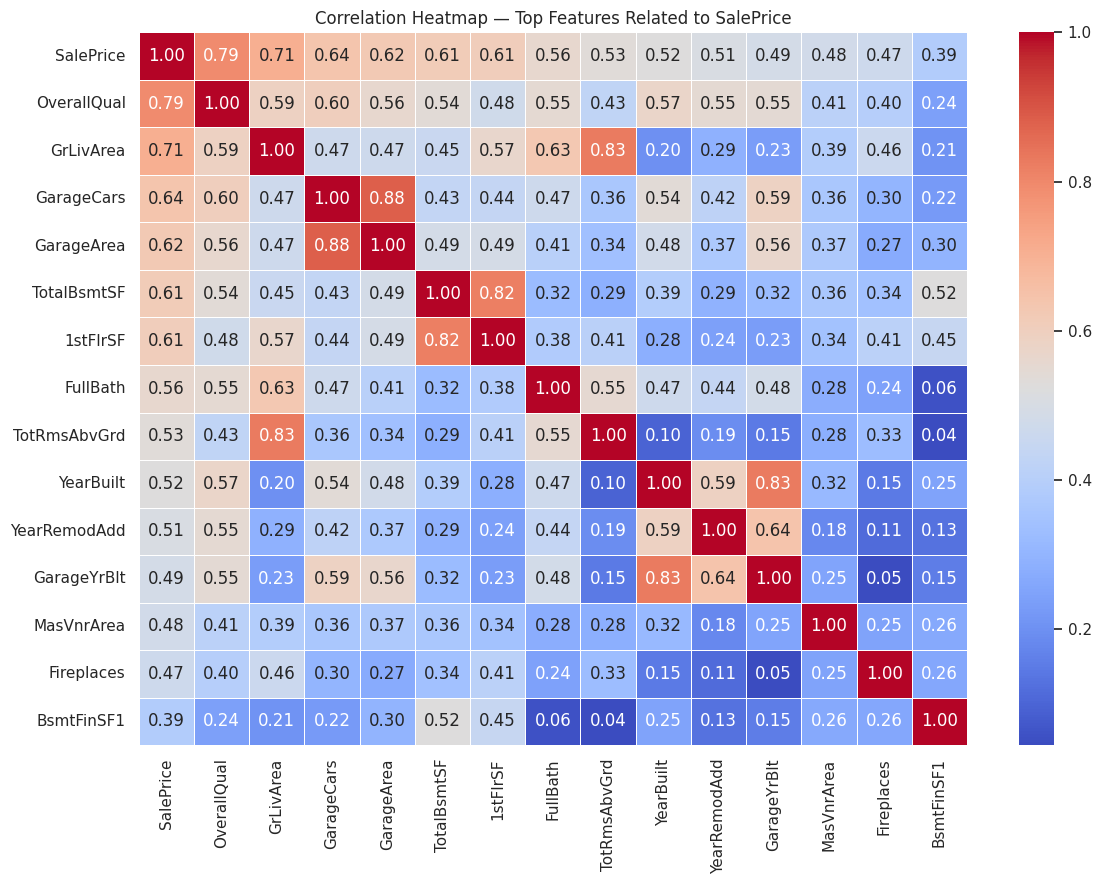

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [ ]:
numeric_data = housing.select_dtypes(include=["int64", "float64"])

corr = numeric_data.corr(numeric_only=True)
top_corr_features = corr[TARGET].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 9))
sns.heatmap(
    housing[top_corr_features].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap — Top Features Related to SalePrice")
plt.tight_layout()
plt.show()

corr[TARGET].sort_values(ascending=False).head(15)

## 8. Strong Numeric Price Drivers

I visualize some of the most important numeric relationships with `SalePrice`.

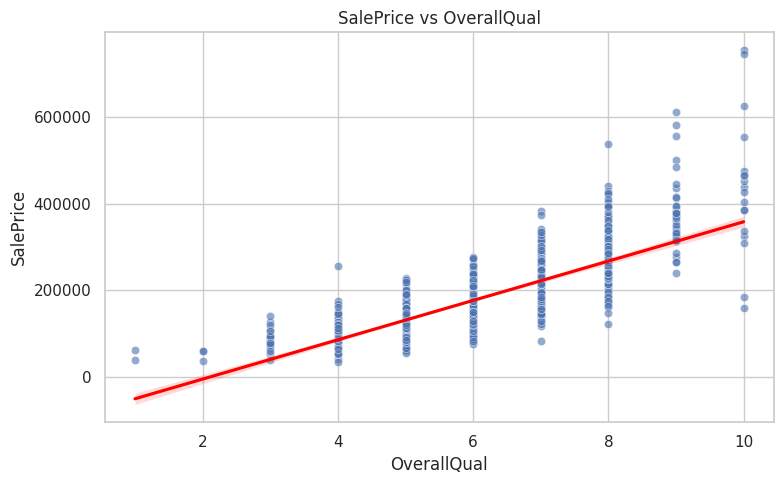

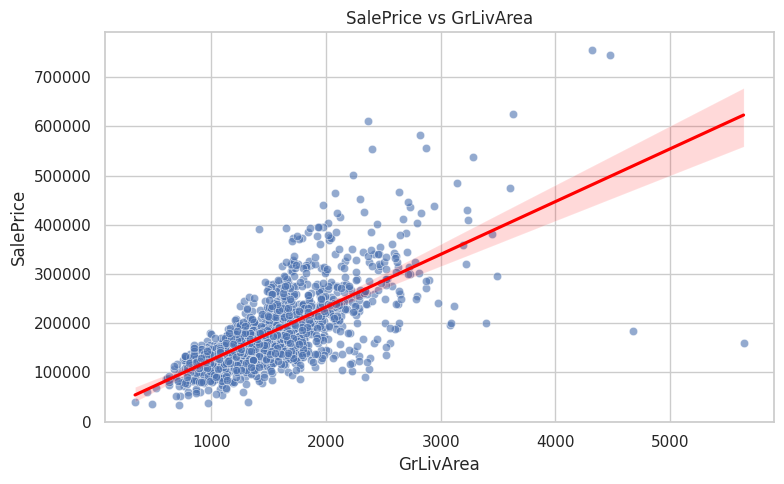

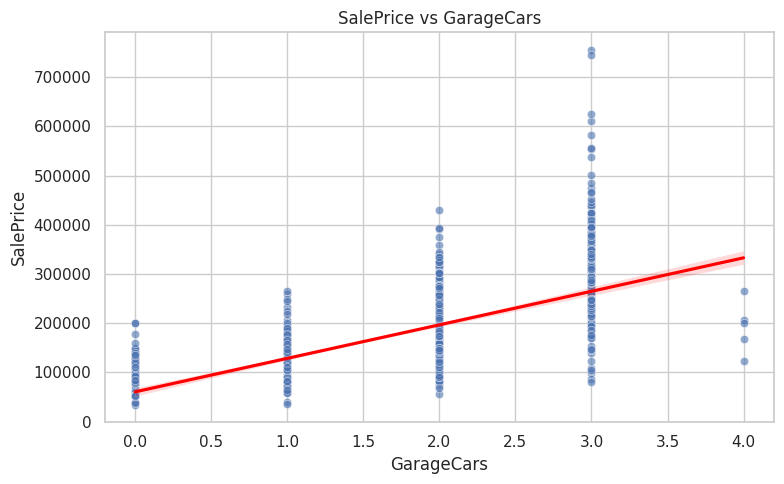

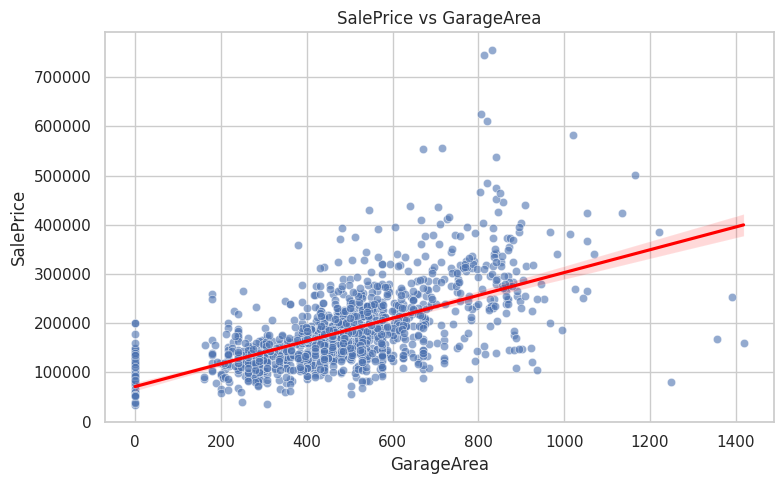

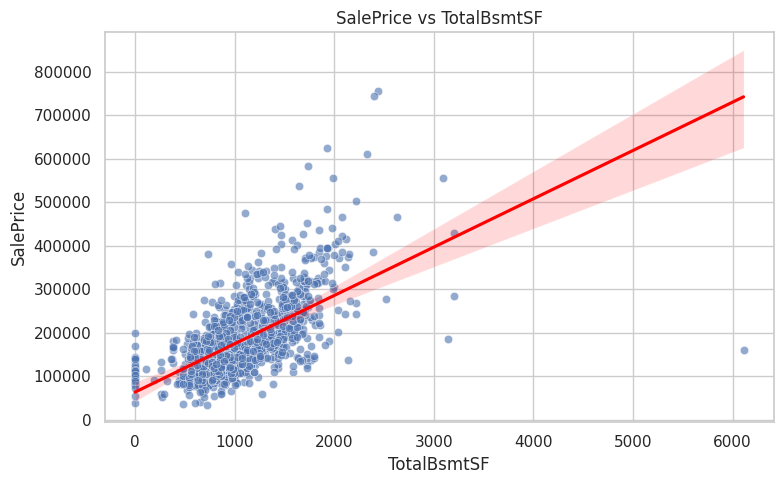

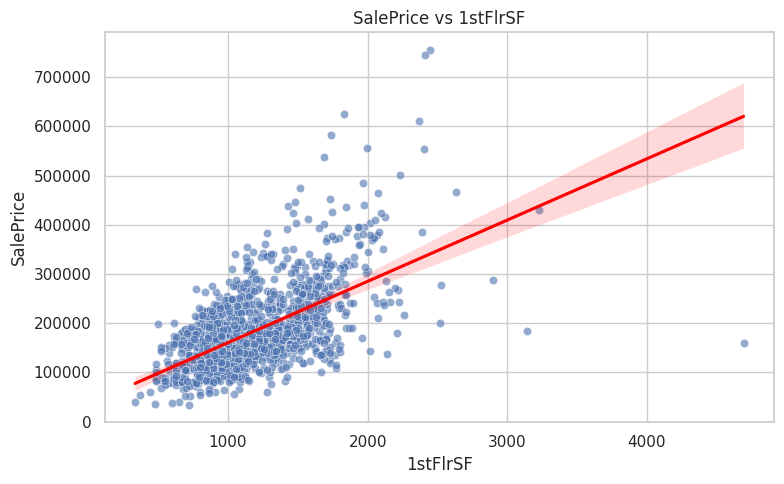

In [ ]:
top_numeric_predictors = (
    corr[TARGET]
    .abs()
    .sort_values(ascending=False)
    .drop(TARGET)
    .head(6)
    .index
    .tolist()
)

for col in top_numeric_predictors:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=housing, x=col, y=TARGET, alpha=0.6)
    sns.regplot(data=housing, x=col, y=TARGET, scatter=False, color="red")
    plt.title(f"SalePrice vs {col}")
    plt.tight_layout()
    plt.show()

## 9. Categorical Feature Visualizations

Categorical variables can be very powerful in housing data.  
I focus on features with a reasonable number of categories so the charts stay readable.

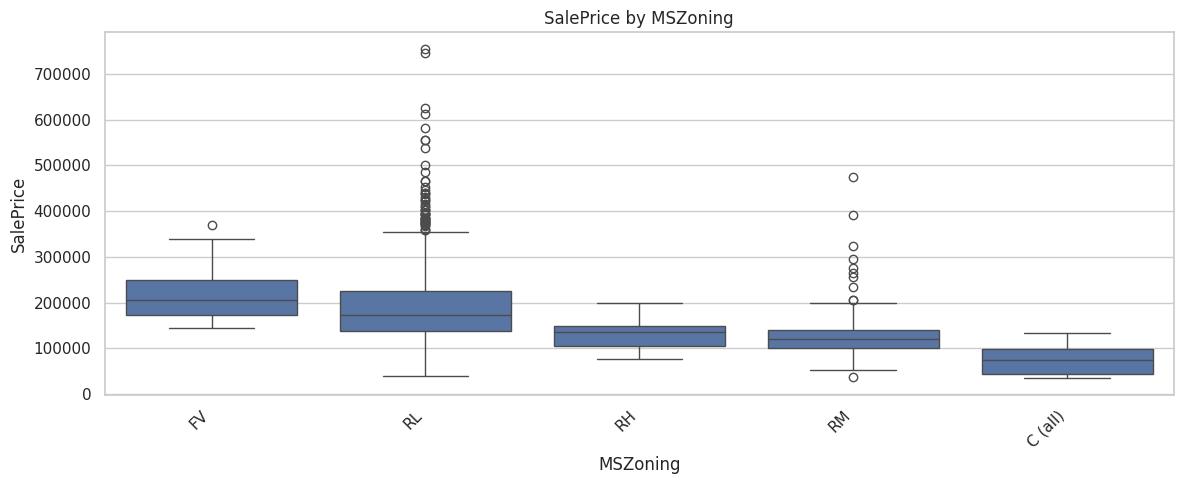

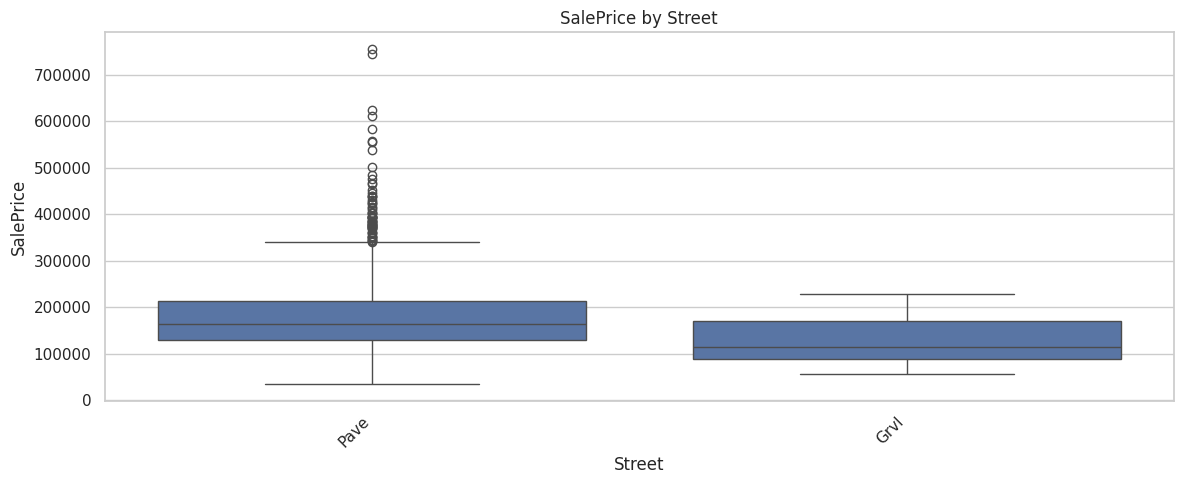

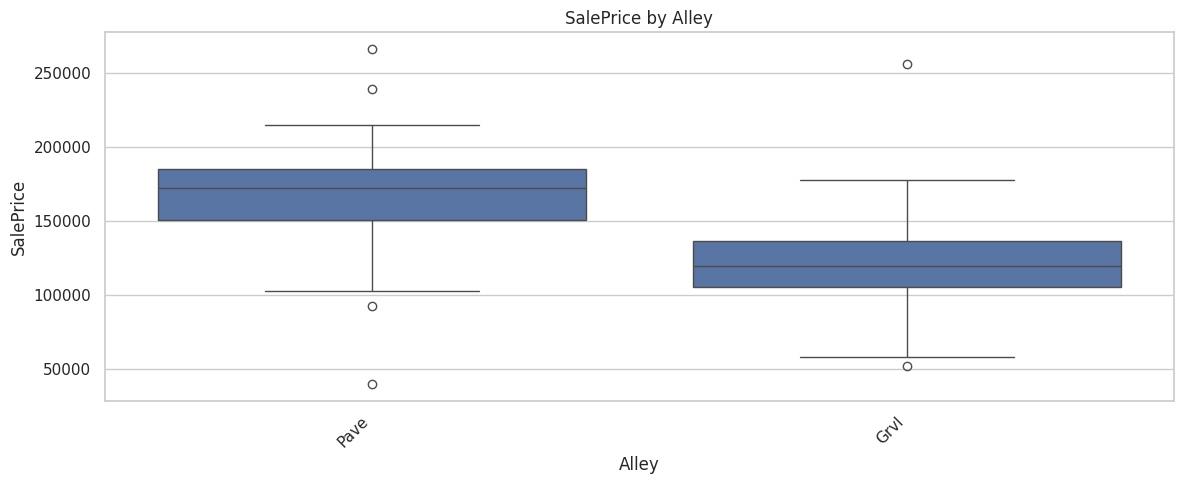

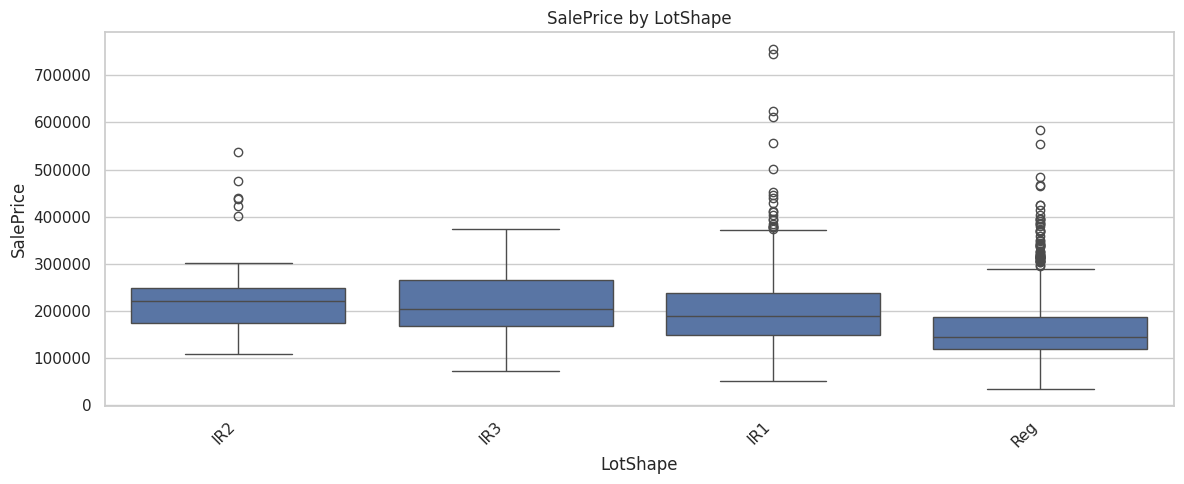

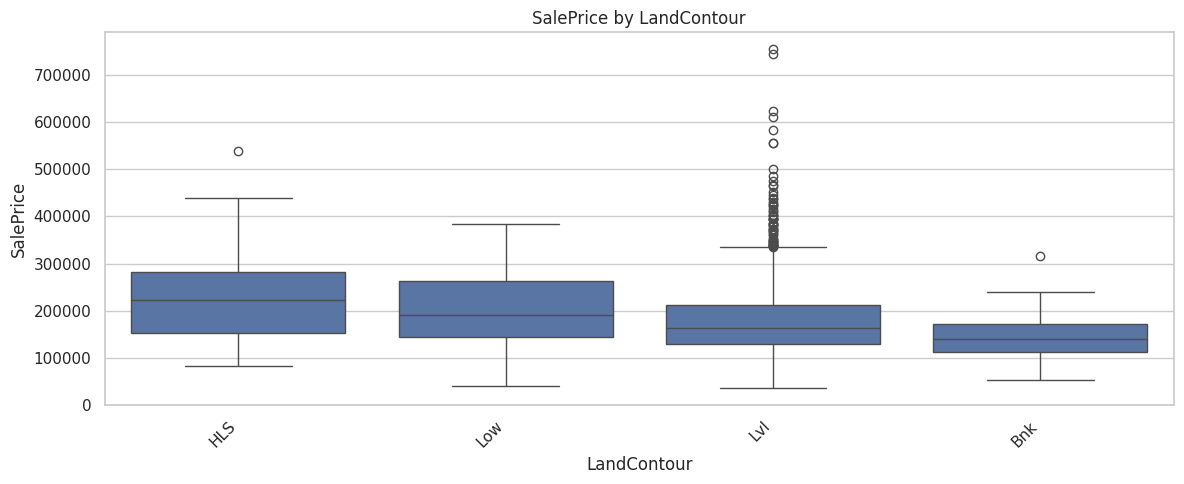

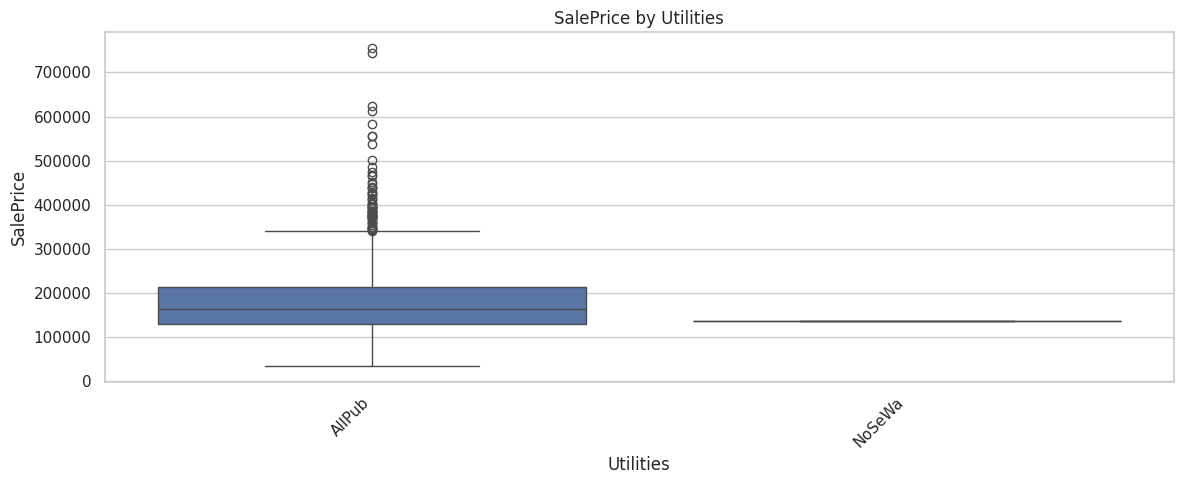

In [ ]:
candidate_categorical = [
    col for col in categorical_cols
    if housing[col].nunique(dropna=True) <= 20
]

for col in candidate_categorical[:6]:
    order = housing.groupby(col)[TARGET].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 5))
    sns.boxplot(data=housing, x=col, y=TARGET, order=order)
    plt.title(f"SalePrice by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 10. Neighborhood Price Analysis

Neighborhood is usually one of the most important housing market signals.  
This chart makes the price differences between neighborhoods very visible.

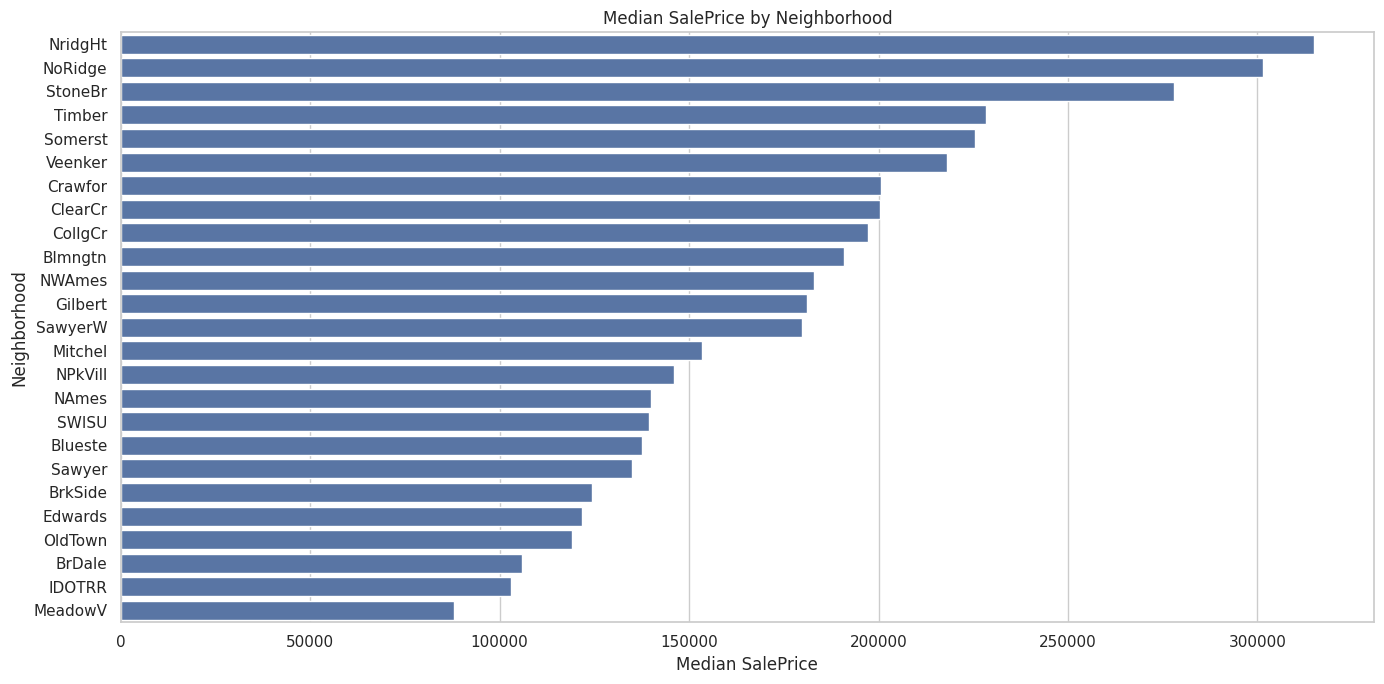

In [ ]:
if "Neighborhood" in housing.columns:
    neighborhood_prices = (
        housing.groupby("Neighborhood")[TARGET]
        .median()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(14, 7))
    sns.barplot(x=neighborhood_prices.values, y=neighborhood_prices.index)
    plt.title("Median SalePrice by Neighborhood")
    plt.xlabel("Median SalePrice")
    plt.ylabel("Neighborhood")
    plt.tight_layout()
    plt.show()

    neighborhood_prices.head(15)
else:
    print("Neighborhood column was not found in the dataset.")

## 11. Feature Engineering

I add a few simple engineered features that make sense for housing data.

These features try to capture:

- total usable space
- house age
- remodeling age
- total bathrooms
- porch/deck area
- whether the house has a garage

In [ ]:
df = housing.copy()

if {"TotalBsmtSF", "GrLivArea"}.issubset(df.columns):
    df["TotalLivingArea"] = df["TotalBsmtSF"] + df["GrLivArea"]

if {"YrSold", "YearBuilt"}.issubset(df.columns):
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

if {"YrSold", "YearRemodAdd"}.issubset(df.columns):
    df["YearsSinceRemodel"] = df["YrSold"] - df["YearRemodAdd"]

bath_cols = ["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"]
if set(bath_cols).issubset(df.columns):
    df["TotalBathrooms"] = (
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"]
    )

porch_cols = ["OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "WoodDeckSF"]
existing_porch_cols = [col for col in porch_cols if col in df.columns]
if existing_porch_cols:
    df["TotalOutdoorArea"] = df[existing_porch_cols].sum(axis=1)

if "GarageArea" in df.columns:
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)

print("New dataset shape after feature engineering:", df.shape)

new_features = [
    col for col in [
        "TotalLivingArea", "HouseAge", "YearsSinceRemodel",
        "TotalBathrooms", "TotalOutdoorArea", "HasGarage"
    ]
    if col in df.columns
]

df[new_features + [TARGET]].head()

New dataset shape after feature engineering: (1460, 87)


,TotalLivingArea,HouseAge,YearsSinceRemodel,TotalBathrooms,TotalOutdoorArea,HasGarage,SalePrice
0,2566,5,5,3.5,61,1,208500
1,2524,31,31,2.5,298,1,181500
2,2706,7,6,3.5,42,1,223500
3,2473,91,36,2.0,307,1,140000
4,3343,8,8,3.5,276,1,250000


## 12. Engineered Feature Visualizations

Now I check whether the engineered features are actually meaningful.

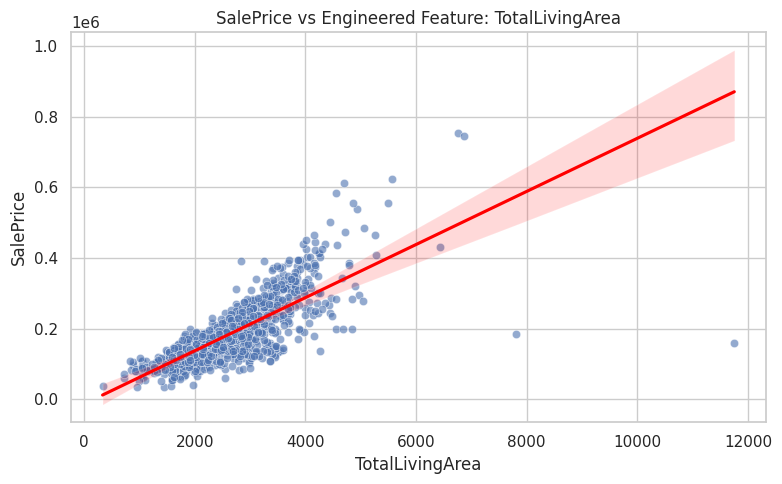

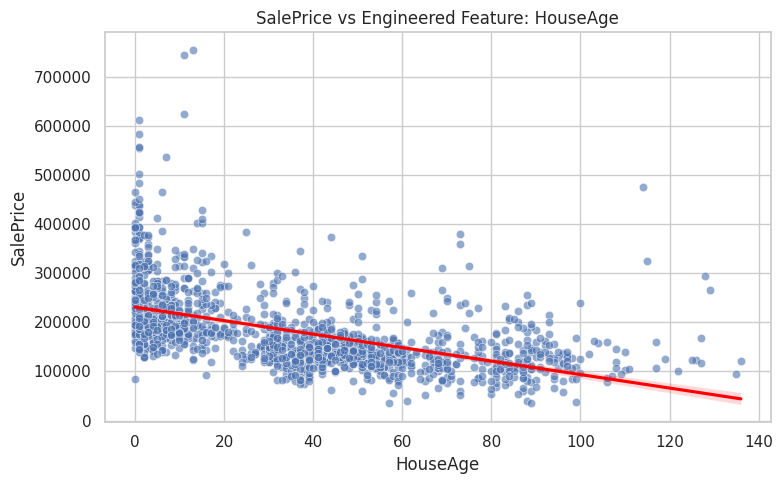

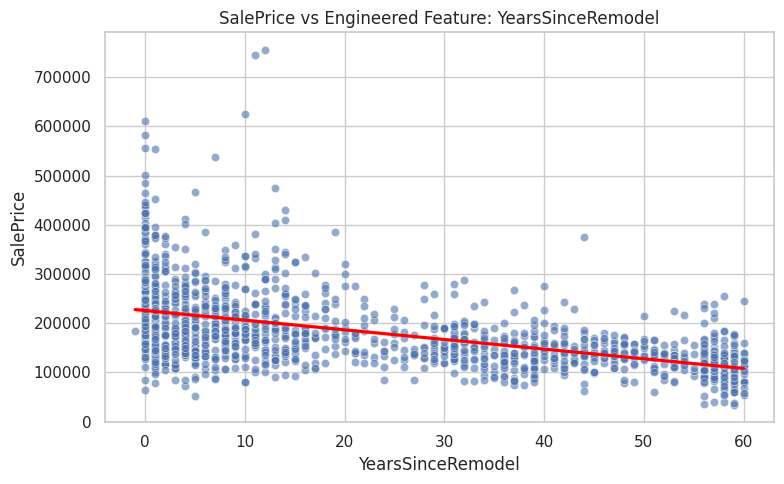

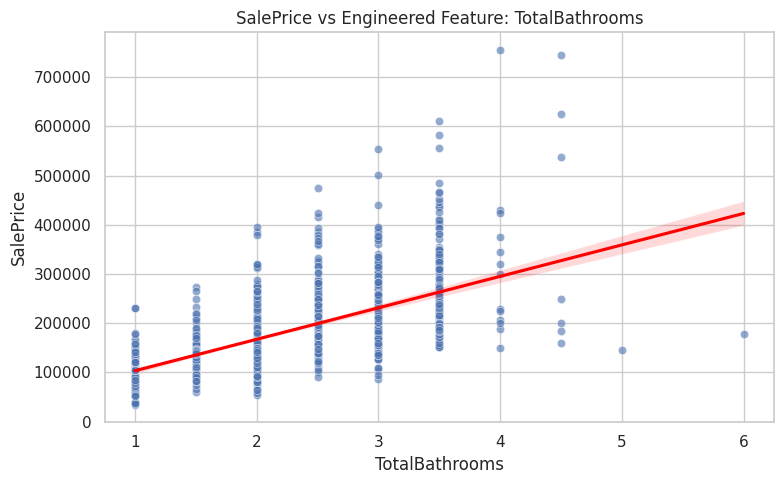

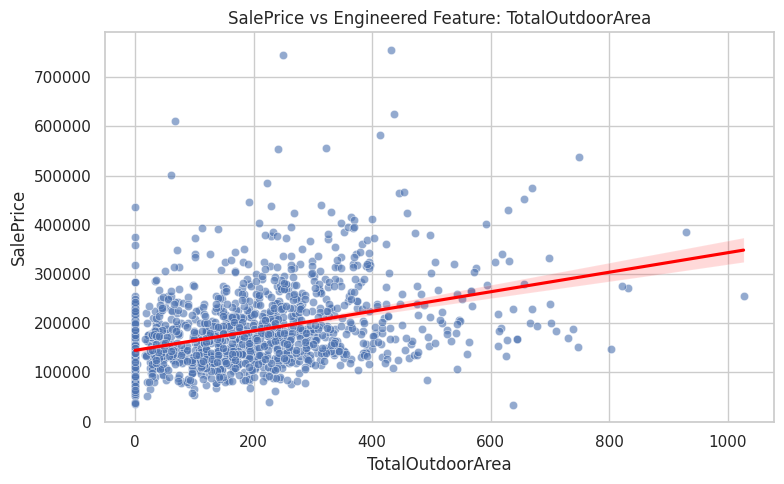

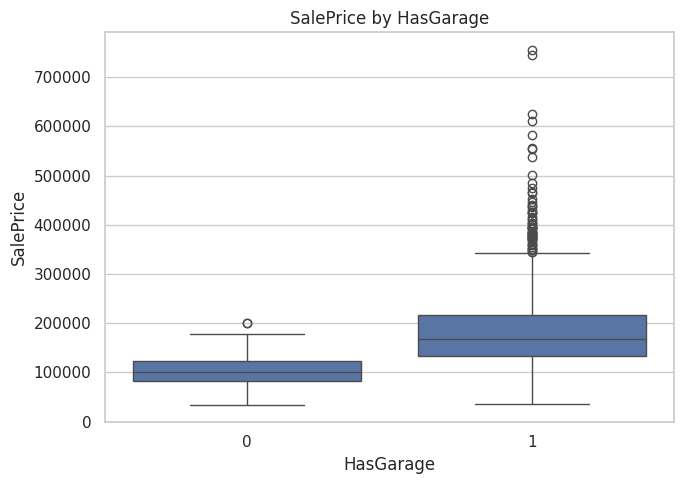

In [ ]:
for col in new_features:
    if df[col].nunique() > 2:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x=col, y=TARGET, alpha=0.6)
        sns.regplot(data=df, x=col, y=TARGET, scatter=False, color="red")
        plt.title(f"SalePrice vs Engineered Feature: {col}")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(7, 5))
        sns.boxplot(data=df, x=col, y=TARGET)
        plt.title(f"SalePrice by {col}")
        plt.tight_layout()
        plt.show()

## 13. Train-Test Split

I separate features from the target and create a train-test split.

In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (1168, 86)
Testing features: (292, 86)


## 14. Preprocessing Pipeline

The pipeline handles numeric and categorical features separately.

- numeric columns: median imputation + scaling
- categorical columns: most frequent imputation + one-hot encoding

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 43
Categorical features: 43


## 15. Evaluation Function

I use MAE, RMSE and R² to evaluate models.

- **MAE**: average absolute error
- **RMSE**: penalizes larger mistakes more strongly
- **R²**: explains how much variance the model captures

In [ ]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Predictions": predictions,
        "Pipeline": model
    }

## 16. Model Training

I train three models:

1. Linear Regression as a simple baseline
2. Random Forest as a strong tree-based model
3. XGBoost as the advanced boosting model

In [ ]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=10))
])

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

xgboost_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

results = []

for name, model in [
    ("Linear Regression", linear_model),
    ("Ridge Regression", ridge_model),
    ("Random Forest", random_forest_model),
    ("XGBoost", xgboost_model)
]:
    print(f"Training {name}...")
    results.append(evaluate_model(name, model, X_train, X_test, y_train, y_test))

model_results = pd.DataFrame([
    {k: v for k, v in result.items() if k not in ["Predictions", "Pipeline"]}
    for result in results
]).sort_values("RMSE")

model_results

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training XGBoost...


,Model,MAE,RMSE,R2
3,XGBoost,15324.623047,24806.672651,0.919773
0,Linear Regression,18213.648607,29419.731805,0.887160
2,Random Forest,17593.709578,29528.924326,0.886321
1,Ridge Regression,18860.184478,30497.904489,0.878738


## 17. Model Comparison Visualizations

Now I compare the models visually.  
The lower the MAE/RMSE, the better.  
The higher the R², the better.

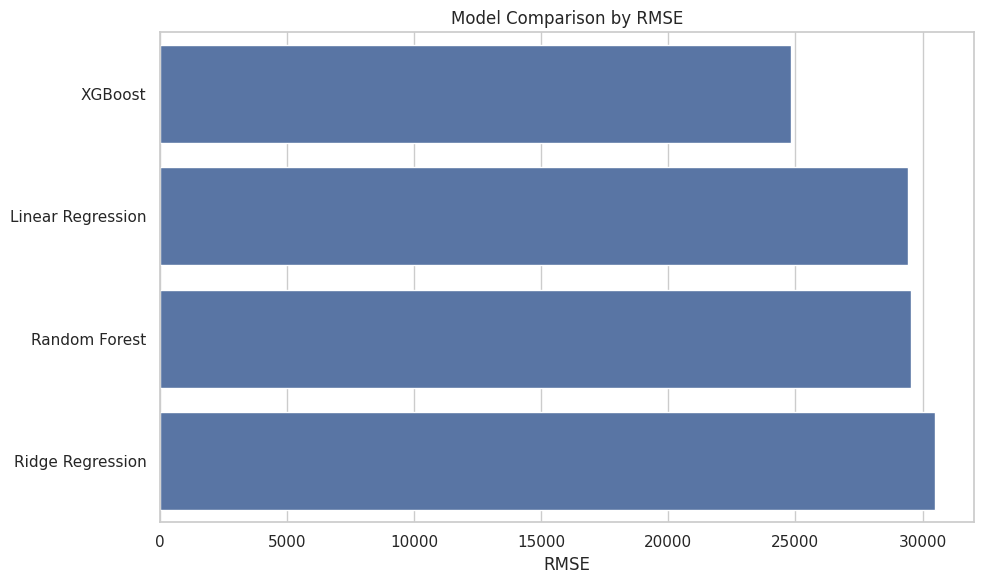

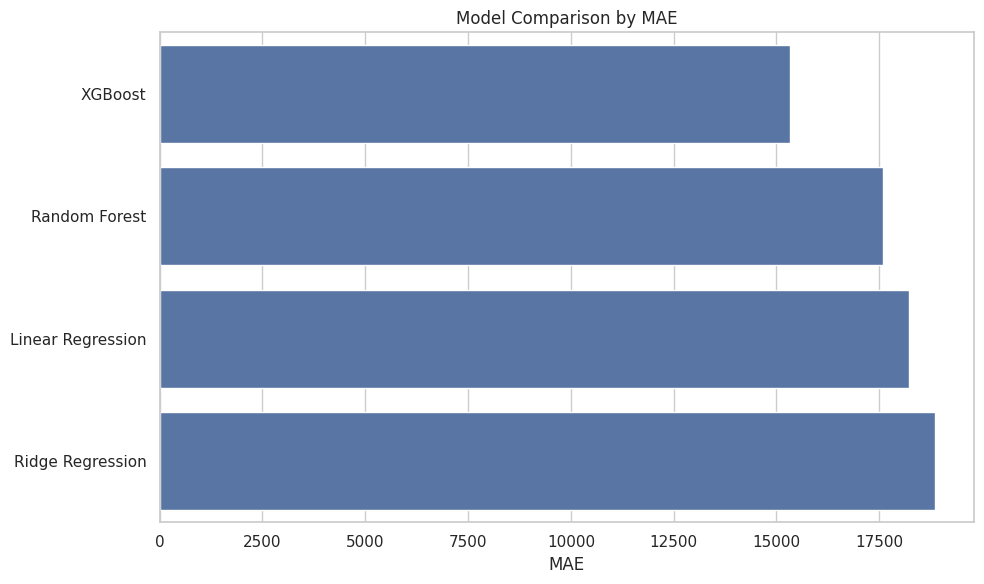

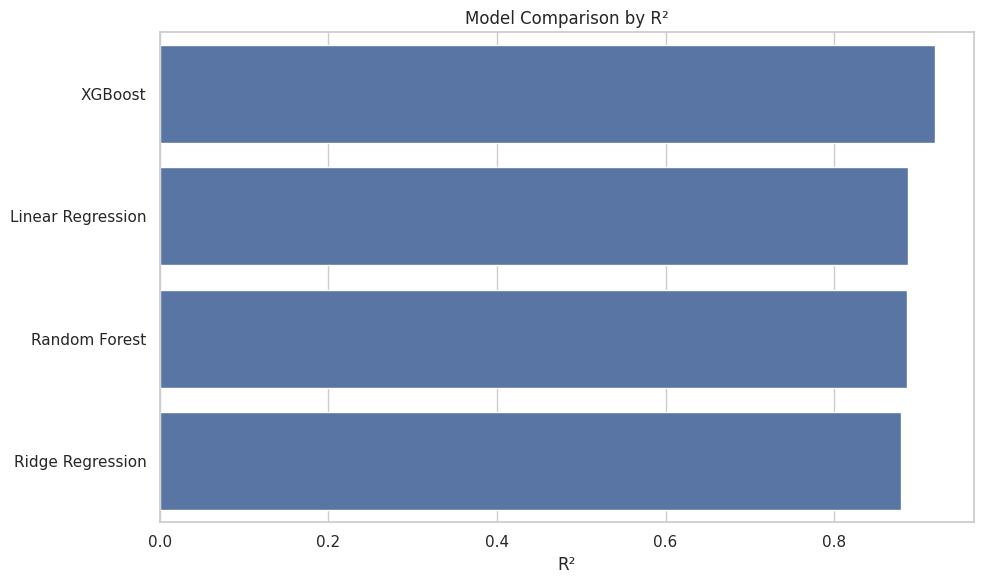

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=model_results, x="RMSE", y="Model")
plt.title("Model Comparison by RMSE")
plt.xlabel("RMSE")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=model_results.sort_values("MAE"), x="MAE", y="Model")
plt.title("Model Comparison by MAE")
plt.xlabel("MAE")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=model_results.sort_values("R2", ascending=False), x="R2", y="Model")
plt.title("Model Comparison by R²")
plt.xlabel("R²")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 18. Actual vs Predicted Prices

This plot shows how close the predictions are to the true sale prices.  
A perfect model would place every point exactly on the diagonal line.

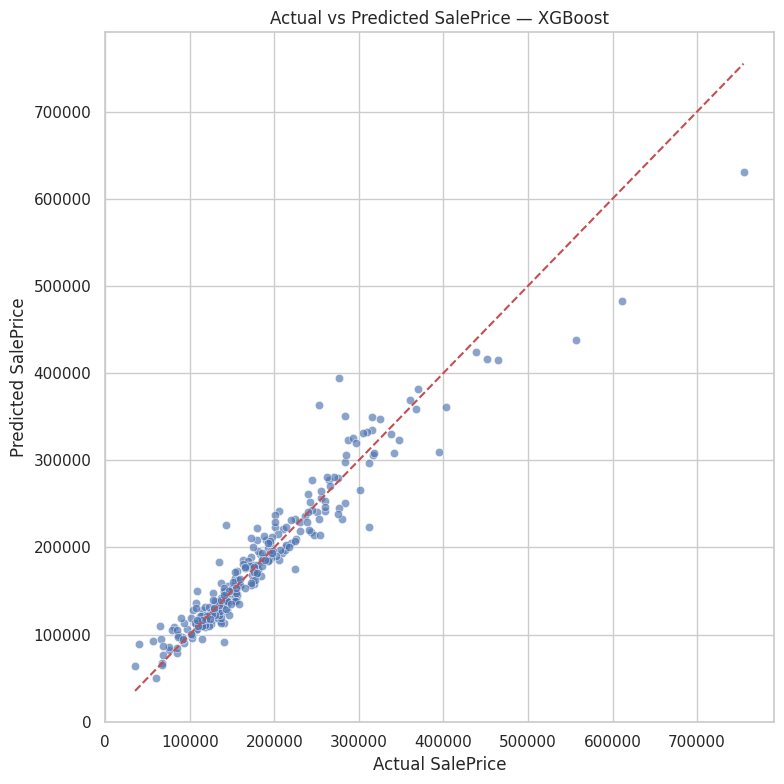

Best model: XGBoost


In [ ]:
best_result = sorted(results, key=lambda x: x["RMSE"])[0]
best_model_name = best_result["Model"]
best_predictions = best_result["Predictions"]

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.65)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title(f"Actual vs Predicted SalePrice — {best_model_name}")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.tight_layout()
plt.show()

print("Best model:", best_model_name)

## 19. Residual Analysis

Residuals show the prediction errors.  
I want them to be centered around zero without a strong pattern.

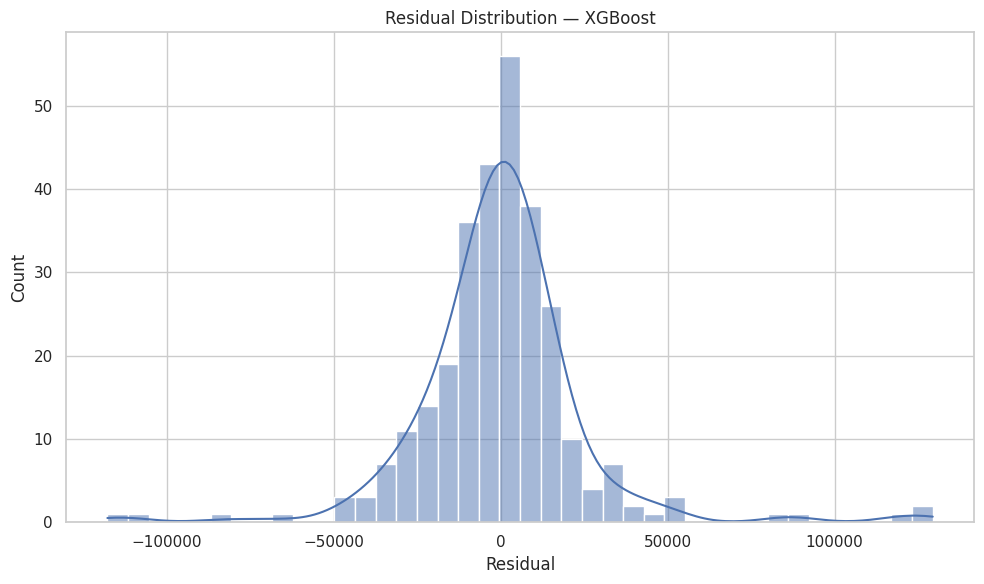

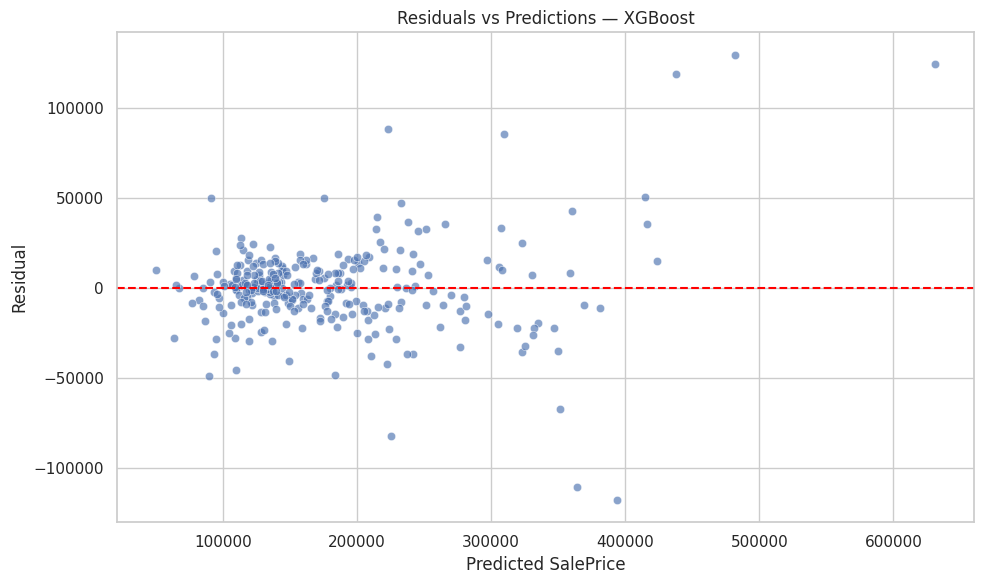

In [ ]:
residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=40)
plt.title(f"Residual Distribution — {best_model_name}")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.65)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residuals vs Predictions — {best_model_name}")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

## 20. Error Percentage Distribution

This makes the model error easier to understand in business terms.

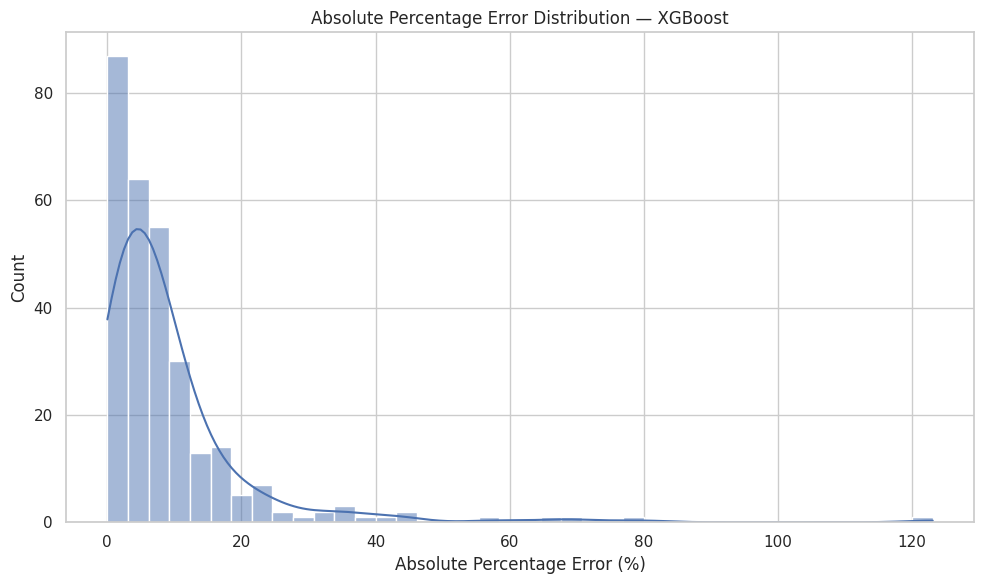

Median absolute percentage error: 6.02%
Mean absolute percentage error: 9.11%


In [ ]:
error_percentage = np.abs((y_test - best_predictions) / y_test) * 100

plt.figure(figsize=(10, 6))
sns.histplot(error_percentage, kde=True, bins=40)
plt.title(f"Absolute Percentage Error Distribution — {best_model_name}")
plt.xlabel("Absolute Percentage Error (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Median absolute percentage error: {np.median(error_percentage):.2f}%")
print(f"Mean absolute percentage error: {np.mean(error_percentage):.2f}%")

# Feature Selection

Now I add a full feature selection section.

This is where the project becomes more advanced.  
Instead of simply training models on every feature, I test which variables actually matter.

## 21. Prepare Encoded Feature Matrix

For feature selection, I transform the data into a numeric matrix first.

In [ ]:
preprocessor_fs = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features)
    ]
)

X_train_encoded = preprocessor_fs.fit_transform(X_train)
X_test_encoded = preprocessor_fs.transform(X_test)

feature_names = preprocessor_fs.get_feature_names_out()

X_train_encoded = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

print("Encoded training data:", X_train_encoded.shape)
print("Encoded testing data:", X_test_encoded.shape)

Encoded training data: (1168, 292)
Encoded testing data: (292, 292)


## 22. Variance Threshold

Variance Threshold removes features that barely change.  
If a feature is almost constant, it usually does not help much.

In [ ]:
variance_selector = VarianceThreshold(threshold=0.01)

X_train_var = variance_selector.fit_transform(X_train_encoded)
X_test_var = variance_selector.transform(X_test_encoded)

selected_var_features = X_train_encoded.columns[variance_selector.get_support()].tolist()

print("Features before variance filtering:", X_train_encoded.shape[1])
print("Features after variance filtering:", len(selected_var_features))

Features before variance filtering: 292
Features after variance filtering: 206


## 23. Correlation Filtering

Highly correlated features can duplicate information.  
Here I remove one feature from pairs with correlation above 0.90.

In [ ]:
corr_matrix = X_train_encoded.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.90)
]

X_train_corr = X_train_encoded.drop(columns=high_corr_features)
X_test_corr = X_test_encoded.drop(columns=high_corr_features)

print("Highly correlated features removed:", len(high_corr_features))
print("Shape after correlation filtering:", X_train_corr.shape)

Highly correlated features removed: 17
Shape after correlation filtering: (1168, 275)


## 24. SelectKBest

SelectKBest uses a supervised statistical test to select the strongest features.

In [ ]:
k = min(40, X_train_encoded.shape[1])

kbest_selector = SelectKBest(score_func=f_regression, k=k)

X_train_kbest = kbest_selector.fit_transform(X_train_encoded, y_train)
X_test_kbest = kbest_selector.transform(X_test_encoded)

selected_kbest_features = X_train_encoded.columns[kbest_selector.get_support()].tolist()

print("Selected features with SelectKBest:", len(selected_kbest_features))
selected_kbest_features[:20]

Selected features with SelectKBest: 40


['num__OverallQual',
 'num__YearBuilt',
 'num__YearRemodAdd',
 'num__MasVnrArea',
 'num__BsmtFinSF1',
 'num__TotalBsmtSF',
 'num__1stFlrSF',
 'num__GrLivArea',
 'num__FullBath',
 'num__TotRmsAbvGrd',
 'num__Fireplaces',
 'num__GarageYrBlt',
 'num__GarageCars',
 'num__GarageArea',
 'num__WoodDeckSF',
 'num__TotalLivingArea',
 'num__HouseAge',
 'num__YearsSinceRemodel',
 'num__TotalBathrooms',
 'num__TotalOutdoorArea']

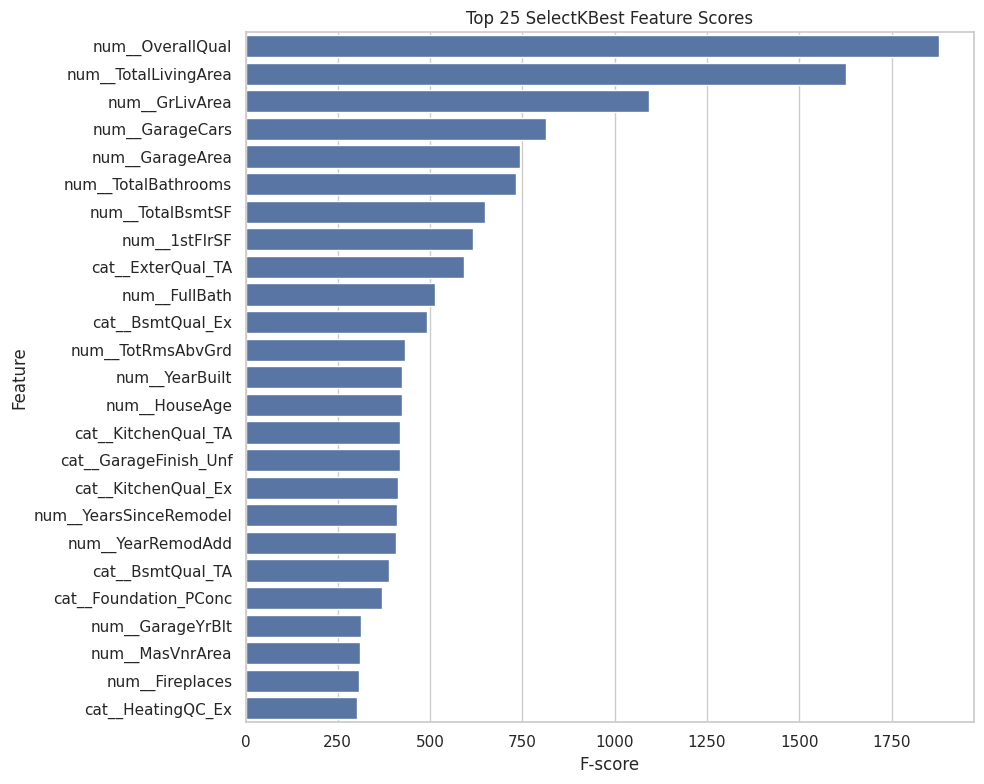

,Feature,Score
4,num__OverallQual,1879.151818
37,num__TotalLivingArea,1627.066448
16,num__GrLivArea,1093.390361
26,num__GarageCars,813.186816
27,num__GarageArea,744.064301
40,num__TotalBathrooms,732.989860
12,num__TotalBsmtSF,648.289096
13,num__1stFlrSF,615.803607
175,cat__ExterQual_TA,591.973984
19,num__FullBath,512.439469


In [ ]:
kbest_scores = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Score": kbest_selector.scores_
}).replace([np.inf, -np.inf], np.nan).dropna().sort_values("Score", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=kbest_scores.head(25), x="Score", y="Feature")
plt.title("Top 25 SelectKBest Feature Scores")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

kbest_scores.head(25)

## 25. SelectFromModel with XGBoost

Here I use XGBoost itself to decide which features are important enough to keep.

In [ ]:
sfm_estimator = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

sfm_selector = SelectFromModel(
    estimator=sfm_estimator,
    threshold="median"
)

X_train_sfm = sfm_selector.fit_transform(X_train_encoded, y_train)
X_test_sfm = sfm_selector.transform(X_test_encoded)

selected_sfm_features = X_train_encoded.columns[sfm_selector.get_support()].tolist()

print("Selected features with SelectFromModel:", len(selected_sfm_features))
selected_sfm_features[:20]

Selected features with SelectFromModel: 146


['num__Id',
 'num__MSSubClass',
 'num__LotFrontage',
 'num__LotArea',
 'num__OverallQual',
 'num__OverallCond',
 'num__YearBuilt',
 'num__YearRemodAdd',
 'num__MasVnrArea',
 'num__BsmtFinSF1',
 'num__BsmtFinSF2',
 'num__BsmtUnfSF',
 'num__TotalBsmtSF',
 'num__1stFlrSF',
 'num__2ndFlrSF',
 'num__GrLivArea',
 'num__BsmtFullBath',
 'num__BsmtHalfBath',
 'num__FullBath',
 'num__BedroomAbvGr']

## 26. Recursive Feature Elimination

RFE removes weaker features step by step.  
I use Ridge regression here because it is fast and stable.

In [ ]:
rfe_feature_count = min(30, X_train_encoded.shape[1])

rfe_selector = RFE(
    estimator=Ridge(alpha=10),
    n_features_to_select=rfe_feature_count,
    step=10
)

X_train_rfe = rfe_selector.fit_transform(X_train_encoded, y_train)
X_test_rfe = rfe_selector.transform(X_test_encoded)

selected_rfe_features = X_train_encoded.columns[rfe_selector.get_support()].tolist()

print("Selected features with RFE:", len(selected_rfe_features))
selected_rfe_features[:20]

Selected features with RFE: 30


['num__OverallQual',
 'num__GrLivArea',
 'cat__LotShape_IR2',
 'cat__LandContour_Bnk',
 'cat__LandContour_HLS',
 'cat__LotConfig_CulDSac',
 'cat__Neighborhood_Edwards',
 'cat__Neighborhood_NoRidge',
 'cat__Neighborhood_NridgHt',
 'cat__Neighborhood_Somerst',
 'cat__Neighborhood_StoneBr',
 'cat__Condition1_Norm',
 'cat__Condition2_PosN',
 'cat__BldgType_1Fam',
 'cat__HouseStyle_1Story',
 'cat__RoofMatl_ClyTile',
 'cat__Exterior1st_BrkFace',
 'cat__Exterior2nd_ImStucc',
 'cat__Exterior2nd_Stucco',
 'cat__BsmtQual_Ex']

## 27. Feature Selection Model Comparison

Now I train XGBoost on different selected feature sets and compare the results.

In [ ]:
def evaluate_encoded_model(model_name, X_train_data, X_test_data, y_train, y_test):
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_data, y_train)
    preds = model.predict(X_test_data)

    return {
        "Model": model_name,
        "Features": X_train_data.shape[1],
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
        "Predictions": preds,
        "Estimator": model
    }

fs_results = []

fs_results.append(evaluate_encoded_model(
    "XGBoost - all encoded features",
    X_train_encoded,
    X_test_encoded,
    y_train,
    y_test
))

fs_results.append(evaluate_encoded_model(
    "XGBoost - variance threshold",
    pd.DataFrame(X_train_var),
    pd.DataFrame(X_test_var),
    y_train,
    y_test
))

fs_results.append(evaluate_encoded_model(
    "XGBoost - correlation filtered",
    X_train_corr,
    X_test_corr,
    y_train,
    y_test
))

fs_results.append(evaluate_encoded_model(
    "XGBoost - SelectKBest",
    pd.DataFrame(X_train_kbest),
    pd.DataFrame(X_test_kbest),
    y_train,
    y_test
))

fs_results.append(evaluate_encoded_model(
    "XGBoost - SelectFromModel",
    pd.DataFrame(X_train_sfm),
    pd.DataFrame(X_test_sfm),
    y_train,
    y_test
))

fs_results.append(evaluate_encoded_model(
    "XGBoost - RFE",
    pd.DataFrame(X_train_rfe),
    pd.DataFrame(X_test_rfe),
    y_train,
    y_test
))

fs_comparison = pd.DataFrame([
    {k: v for k, v in result.items() if k not in ["Predictions", "Estimator"]}
    for result in fs_results
]).sort_values("RMSE")

fs_comparison

,Model,Features,MAE,RMSE,R2
2,XGBoost - correlation filtered,275,15090.988281,24139.151269,0.924032
4,XGBoost - SelectFromModel,146,15109.095703,24263.774480,0.923246
1,XGBoost - variance threshold,206,15309.267578,24669.494036,0.920657
0,XGBoost - all encoded features,292,15324.623047,24806.672651,0.919773
3,XGBoost - SelectKBest,40,17962.437500,27016.877688,0.904840
5,XGBoost - RFE,30,19796.427734,28886.823571,0.891211


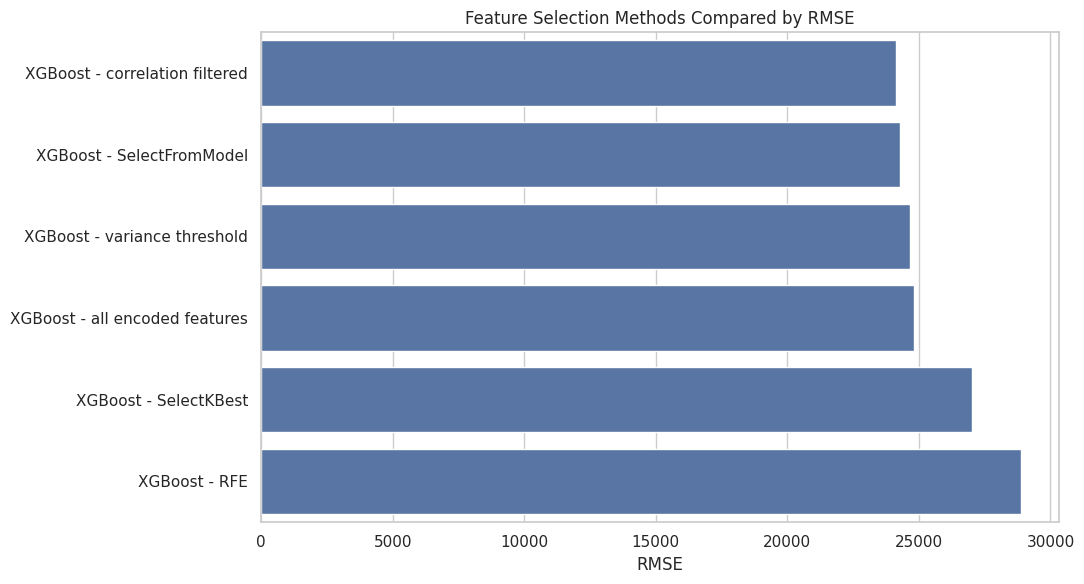

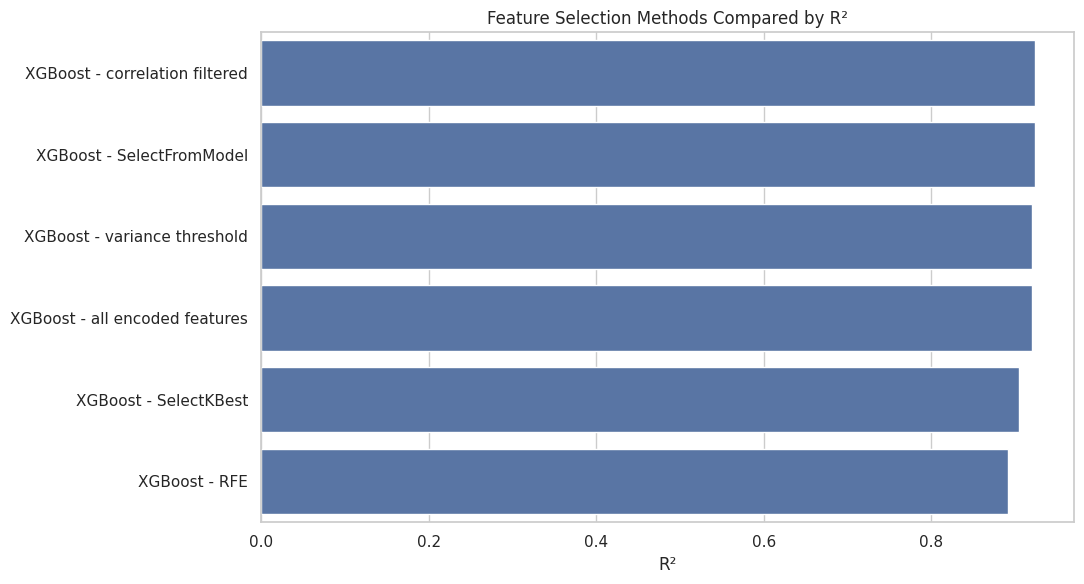

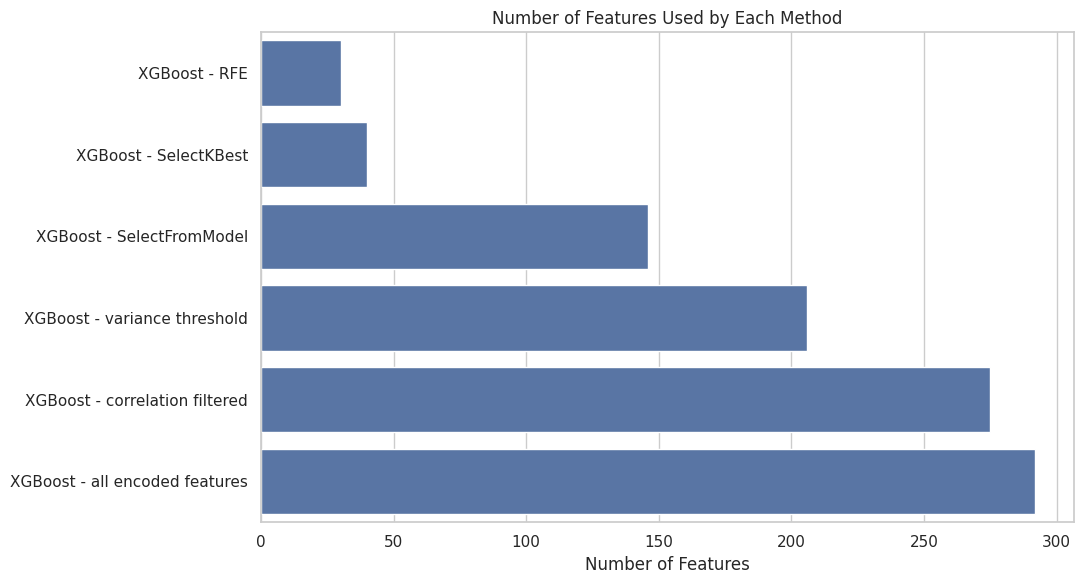

In [ ]:
plt.figure(figsize=(11, 6))
sns.barplot(data=fs_comparison, x="RMSE", y="Model")
plt.title("Feature Selection Methods Compared by RMSE")
plt.xlabel("RMSE")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.barplot(data=fs_comparison.sort_values("R2", ascending=False), x="R2", y="Model")
plt.title("Feature Selection Methods Compared by R²")
plt.xlabel("R²")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.barplot(data=fs_comparison.sort_values("Features"), x="Features", y="Model")
plt.title("Number of Features Used by Each Method")
plt.xlabel("Number of Features")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 28. XGBoost Feature Importance

Finally, I look inside the XGBoost model to see which features had the strongest impact.

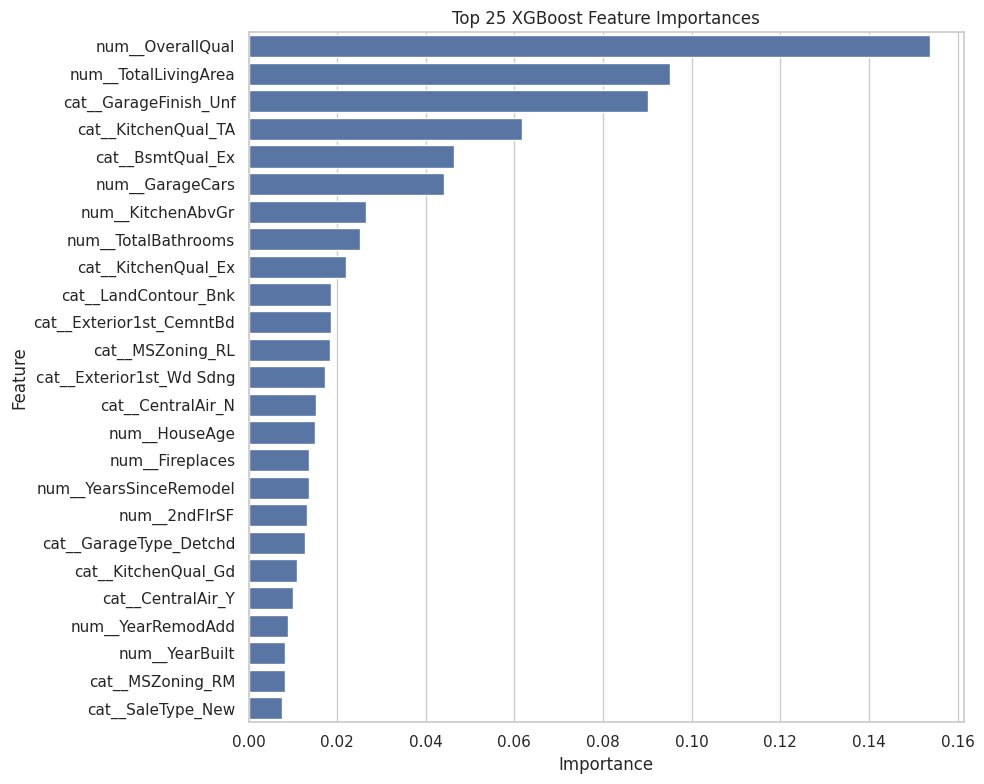

,Feature,Importance
4,num__OverallQual,0.153803
37,num__TotalLivingArea,0.095100
252,cat__GarageFinish_Unf,0.090219
231,cat__KitchenQual_TA,0.061726
187,cat__BsmtQual_Ex,0.046460
26,num__GarageCars,0.044165
22,num__KitchenAbvGr,0.026445
40,num__TotalBathrooms,0.025054
228,cat__KitchenQual_Ex,0.022107
56,cat__LandContour_Bnk,0.018711


In [ ]:
xgb_pipeline = xgboost_model
xgb_pipeline.fit(X_train, y_train)

processed_feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()
xgb_importances = xgb_pipeline.named_steps["model"].feature_importances_

xgb_feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": xgb_importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=xgb_feature_importance.head(25), x="Importance", y="Feature")
plt.title("Top 25 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

xgb_feature_importance.head(25)

## 29. Final Model Summary

At this point, I have:

- explored the housing dataset visually
- engineered meaningful features
- trained several regression models
- added XGBoost as an advanced model
- compared models using MAE, RMSE and R²
- analyzed prediction errors
- used feature selection to understand which variables matter most

This turns the notebook into a complete regression machine learning project.

In [ ]:
print("Best regular model:")
display(model_results.head(1))

print("Best feature selection version:")
display(fs_comparison.head(1))

Best regular model:


,Model,MAE,RMSE,R2
3,XGBoost,15324.623047,24806.672651,0.919773


Best feature selection version:


,Model,Features,MAE,RMSE,R2
2,XGBoost - correlation filtered,275,15090.988281,24139.151269,0.924032


# Final Conclusion

This project started as a housing price regression task, but I turned it into a full machine learning workflow.

The most important part is not only the final score.  
The real value is understanding the process:

- what drives house prices
- which features are useful
- how different models behave
- how prediction errors look
- whether feature selection improves the model

XGBoost and Random Forest are the strongest choices here because housing prices are affected by non-linear relationships and interactions between features.

This notebook is now much closer to a real portfolio-style ML project than a simple classroom exercise.